# 02 · Enron-Spam & SpamAssassin — структура до полной разметки

**Цель:** понять, *есть ли* в этих источниках осмысленные «сценарии фрода» и как распределены `spam` / `ham`, **без** разметки всего корпуса LLM (как для SMS Spam).

**Важно (факт):** в `enron.jsonl` и `spamassassin.jsonl` **нет** отдельного поля вроде `fraud_scenario` или `scenario_family`. Есть только бинарная метка `label` (`spam` / `ham`) плюс служебные поля (`subset` / `archive`, `subject`, …). Любая сценарная структура — это **диагностические прокси** (ключевые слова и простые правила), выровненные с черновой онтологией в `docs/archive/dataset_design_v1.md` §5.2–5.7.

**Что делает ноутбук:**
1. Сводка по метаданным (подмножества Enron, архивы SpamAssassin, длины, URL).
2. Для **spam**: распределение по **приоритетному** первичному классу (одна метка на запись) + таблица **независимых** срабатываний правил (сумма долей может быть >100%).
3. Для **ham**: то же для грубых классов legitimate-style из v1 §5.2 / §5.3.
4. Случайные примеры по каждому первичному классу — для быстрой ручной проверки глазами.
5. Сохранение агрегированных таблиц в `outputs/tables/`.

**Ограничения:** прокси ≠ gold-разметка; конфликтующие классы разрешаются фиксированным порядком приоритета (см. ячейку с правилами).

In [1]:
# ── 0. Setup ───────────────────────────────────────────────────────────────
import json
import re
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _find_v2_root() -> Path:
    candidate = Path(globals().get("__vsc_ipynb_file__",
                     globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")

V2_ROOT    = _find_v2_root()
RAW_DIR    = V2_ROOT / "data" / "raw" / "collected"
OUT_FIGS   = V2_ROOT / "outputs" / "figures" / "structure"
OUT_TABLES = V2_ROOT / "outputs" / "tables"

OUT_FIGS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

print(f"V2_ROOT : {V2_ROOT}")
print(f"RAW_DIR : {RAW_DIR}")

V2_ROOT : /Users/askar/projects/antifraud-deepfake-detection/v2
RAW_DIR : /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected


In [2]:
# ── 1. Load JSONL ──────────────────────────────────────────────────────────
def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]

enron_path = RAW_DIR / "enron.jsonl"
sa_path    = RAW_DIR / "spamassassin.jsonl"
assert enron_path.exists(), enron_path
assert sa_path.exists(), sa_path

enron = load_jsonl(enron_path)
sa    = load_jsonl(sa_path)

print(f"Enron-Spam        : {len(enron):,} records")
print(f"SpamAssassin      : {len(sa):,} records")

Enron-Spam        : 33,716 records
SpamAssassin      : 7,193 records


In [3]:
# ── 2. Metadata inventory (no scenario labels in source) ───────────────────
def summarize_split(records: list[dict], name: str, label_key: str = "label") -> None:
    by_lab = Counter(r.get(label_key) for r in records)
    print(f"\n{name}")
    print(f"  label distribution: {dict(by_lab)}")
    # Enron: subset
    if any("subset" in r for r in records[:5]):
        sp = Counter(r.get("subset", "") for r in records)
        print(f"  subset (top): {sp.most_common(8)}")
    # SA: archive
    if any("archive" in r for r in records[:5]):
        ar = Counter(r.get("archive", "") for r in records)
        print(f"  archive: {dict(ar)}")
    wc = [len((r.get("text") or "").split()) for r in records]
    url = sum(1 for r in records if r.get("has_url"))
    empty = sum(1 for r in records if not (r.get("text") or "").strip())
    print(f"  word_count median: {int(np.median(wc))}, p90: {int(np.percentile(wc, 90))}")
    print(f"  has_url: {url:,} ({100*url/len(records):.1f}%)")
    print(f"  empty text: {empty:,}")

summarize_split(enron, "Enron (all)")
summarize_split(sa, "SpamAssassin (all)")

enron_spam = [r for r in enron if r.get("label") == "spam"]
enron_ham  = [r for r in enron if r.get("label") == "ham"]
sa_spam    = [r for r in sa if r.get("label") == "spam"]
sa_ham     = [r for r in sa if r.get("label") == "ham"]

print("\n── Split sizes ──")
print(f"  Enron spam / ham : {len(enron_spam):,} / {len(enron_ham):,}")
print(f"  SA spam / ham    : {len(sa_spam):,} / {len(sa_ham):,}")


Enron (all)
  label distribution: {'ham': 16545, 'spam': 17171}
  subset (top): [('enron4', 6000), ('enron6', 6000), ('enron2', 5857), ('enron3', 5512), ('enron5', 5175), ('enron1', 5172)]
  word_count median: 146, p90: 632
  has_url: 0 (0.0%)
  empty text: 372

SpamAssassin (all)
  label distribution: {'spam': 3293, 'ham': 3900}
  archive: {'20030228_spam.tar.bz2': 500, '20030228_spam_2.tar.bz2': 1397, '20050311_spam_2.tar.bz2': 1396, '20030228_easy_ham.tar.bz2': 2500, '20030228_easy_ham_2.tar.bz2': 1400}
  word_count median: 144, p90: 493
  has_url: 5,137 (71.4%)
  empty text: 56

── Split sizes ──
  Enron spam / ham : 17,171 / 16,545
  SA spam / ham    : 3,293 / 3,900


## Прокси-классы для **spam** (dataset_design_v1 §5.6–5.7)

Классы совпадают с целевой coarse-онтологией для будущей LLM-разметки:
`phishing_email`, `candidate_419_or_advance_fee`, `promo_marketing_email`, `malware_or_attachment_lure`, `generic_spam_nonphishing`, `unclear_other`.

**Первичный класс** — один на запись: берётся **первое** сработавшее правило из списка приоритета (ниже в коде).  
**Независимые флаги** — для каждого набора ключевых слов считается, сколько записей вообще попадает под правило (пересечения видны по сумме >100%).

In [4]:
# ── 3. Spam heuristic rules (aligned with dataset_design_v1 §5.6) ──────────

def _norm(s: str) -> str:
    return (s or "").lower()

def _has_any(hay: str, kws: tuple[str, ...]) -> bool:
    return any(k in hay for k in kws)

# --- Rule packs (keyword / phrase lists — adjust only after manual audit) ---
KW_419 = (
    "beneficiary", "next of kin", "deceased", "inheritance", "million dollar",
    "barrister", "foreign account", "strictly confidential", "late client",
    "transfer of funds", "funds transfer", "oil contract", "dear friend",
    "dearest beloved", "am contacting you", "good day",
)

KW_PHISH = (
    "verify your account", "confirm your identity", "suspended account",
    "account has been", "unusual activity", "click below", "click here",
    "update your password", "reset your password", "phishing", "e-bay",
    "paypal", "ebay security", "bank account", "routing number",
    "social security number", "ssn", "pin number", "otp",
)

KW_MALWARE = (
    ".exe", ".scr", ".pif", ".zip", "attachment", "virus", "worm",
    "malware", "trojan", "patch.exe", "document.zip",
)

KW_PROMO = (
    "unsubscribe", "opt out", "free quote", "special offer", "limited time",
    "discount", "viagra", "cialis", "weight loss", "mortgage rate",
    "life insurance", "refinance", "casino", "single", "dating",
)

KW_LOTTERY = (  # often overlaps promo — kept as extra independent flag only
    "you have won", "you won", "winner", "lottery", "prize", "claim your",
    "selected you", "cash prize",
)

# Priority order for PRIMARY label (first match wins)
SPAM_PRIORITY = [
    ("candidate_419_or_advance_fee", KW_419),
    ("malware_or_attachment_lure", KW_MALWARE),
    ("phishing_email", KW_PHISH),
    ("promo_marketing_email", KW_PROMO),
]


def spam_independent_flags(text: str) -> dict[str, bool]:
    t = _norm(text)
    return {
        "hit_419": _has_any(t, KW_419),
        "hit_phish": _has_any(t, KW_PHISH),
        "hit_malware": _has_any(t, KW_MALWARE),
        "hit_promo": _has_any(t, KW_PROMO),
        "hit_lottery": _has_any(t, KW_LOTTERY),
    }


def spam_primary_label(text: str) -> str:
    t = _norm(text)
    if not t.strip():
        return "unclear_other"
    for name, kws in SPAM_PRIORITY:
        if _has_any(t, kws):
            return name
    if len(t.split()) < 8:
        return "unclear_other"
    return "generic_spam_nonphishing"


def enrich_spam(records: list[dict]) -> pd.DataFrame:
    rows = []
    for r in records:
        txt = r.get("text") or ""
        prim = spam_primary_label(txt)
        flags = spam_independent_flags(txt)
        rows.append({**r, "spam_primary": prim, **{f"flag_{k}": v for k, v in flags.items()}})
    return pd.DataFrame(rows)

df_es = enrich_spam(enron_spam)
df_ss = enrich_spam(sa_spam)

print("Enron spam — primary (priority) distribution:")
print(df_es["spam_primary"].value_counts().to_string())
print("\nSpamAssassin spam — primary (priority) distribution:")
print(df_ss["spam_primary"].value_counts().to_string())

Enron spam — primary (priority) distribution:
spam_primary
generic_spam_nonphishing        10918
promo_marketing_email            2749
phishing_email                   1814
candidate_419_or_advance_fee      801
unclear_other                     511
malware_or_attachment_lure        378

SpamAssassin spam — primary (priority) distribution:
spam_primary
phishing_email                  1210
generic_spam_nonphishing        1103
promo_marketing_email            598
candidate_419_or_advance_fee     219
malware_or_attachment_lure        87
unclear_other                     76


In [5]:
# ── 4. Spam: independent rule hit rates (overlap visible) ──────────────────
flag_cols = [c for c in df_es.columns if c.startswith("flag_")]

def flag_rates(df: pd.DataFrame, n: int) -> pd.Series:
    return pd.Series({c: 100 * df[c].sum() / max(n, 1) for c in flag_cols})

r_enr = flag_rates(df_es, len(df_es))
r_sa  = flag_rates(df_ss, len(df_ss))
cmp = pd.DataFrame({"enron_spam_%": r_enr, "sa_spam_%": r_sa})
print("Independent keyword-flag hit rates (% of spam rows):")
print(cmp.round(1).to_string())
print("\n(Сумма по строкам может быть >100% — одно письмо может срабатывать на несколько наборов.)")

cmp.to_csv(OUT_TABLES / "enron_sa_spam_keyword_flag_rates.csv")

Independent keyword-flag hit rates (% of spam rows):
                  enron_spam_%  sa_spam_%
flag_hit_419               4.7        6.7
flag_hit_phish            12.3       39.8
flag_hit_malware           2.4        2.7
flag_hit_promo            20.5       42.1
flag_hit_lottery           4.1        5.3

(Сумма по строкам может быть >100% — одно письмо может срабатывать на несколько наборов.)


## Прокси-классы для **ham** (dataset_design_v1 §5.2 Enron ham, §5.3 SA ham)

Целевые классы для будущей диагностической разметки на подвыборке:
`business_email`, `personal_email`, `service_or_system_email`, `informational_notification_email`, `mixed_or_unclear`.

Здесь — грубые эвристики по тексту/subject (Enron — сильный уклон в `business_email` ожидаем).

In [6]:
# ── 5. Ham heuristic rules ─────────────────────────────────────────────────

def combined_ham_text(r: dict) -> str:
    subj = _norm(r.get("subject") or "")
    body = _norm(r.get("text") or "")
    return subj + " \n " + body

KW_SERVICE = (
    "mailer-daemon", "postmaster", "undeliverable", "delivery failure",
    "automatic reply", "auto-reply", "out of office", "out of the office",
    "do not reply", "noreply", "no-reply",
)

KW_INFO = (
    "fyi", "for your information", "reminder", "meeting", "schedule",
    "calendar", "agenda", "attached", "please see attached",
)

KW_BUSINESS = (
    "enron", "ect@", "hou/ect", "forwarded by", "subject : re :",
    "contract", "nomination", "volume", "deal ", "trader", "pipeline",
    "meter ", "allocation", "gross production",
)

KW_PERSONAL = (
    "happy birthday", "weekend", "kids", "vacation", "dinner",
    "love,", "thanks!", "see you",
)

HAM_PRIORITY = [
    ("service_or_system_email", KW_SERVICE),
    ("informational_notification_email", KW_INFO),
    ("business_email", KW_BUSINESS),
    ("personal_email", KW_PERSONAL),
]


def ham_independent_flags(s: str) -> dict[str, bool]:
    return {
        "hit_service": _has_any(s, KW_SERVICE),
        "hit_info": _has_any(s, KW_INFO),
        "hit_business": _has_any(s, KW_BUSINESS),
        "hit_personal": _has_any(s, KW_PERSONAL),
    }


def ham_primary_label(r: dict) -> str:
    s = combined_ham_text(r)
    if not s.strip():
        return "mixed_or_unclear"
    for name, kws in HAM_PRIORITY:
        if _has_any(s, kws):
            return name
    return "mixed_or_unclear"


def enrich_ham(records: list[dict]) -> pd.DataFrame:
    rows = []
    for r in records:
        s = combined_ham_text(r)
        prim = ham_primary_label(r)
        fl = ham_independent_flags(s)
        rows.append({**r, "ham_primary": prim, **{f"hflag_{k}": v for k, v in fl.items()}})
    return pd.DataFrame(rows)

df_eh = enrich_ham(enron_ham)
df_sh = enrich_ham(sa_ham)

print("Enron ham — primary (priority) distribution:")
print(df_eh["ham_primary"].value_counts().to_string())
print("\nSpamAssassin ham — primary (priority) distribution:")
print(df_sh["ham_primary"].value_counts().to_string())

Enron ham — primary (priority) distribution:
ham_primary
informational_notification_email    7773
business_email                      5609
mixed_or_unclear                    2716
personal_email                       249
service_or_system_email              198

SpamAssassin ham — primary (priority) distribution:
ham_primary
mixed_or_unclear                    3376
informational_notification_email     207
business_email                       162
personal_email                       121
service_or_system_email               34


In [7]:
# ── 6. Ham: independent flag rates ────────────────────────────────────────
hflag_cols = [c for c in df_eh.columns if c.startswith("hflag_")]

def hflag_rates(df: pd.DataFrame) -> pd.Series:
    n = len(df)
    return pd.Series({c: 100 * df[c].sum() / max(n, 1) for c in hflag_cols})

hcmp = pd.DataFrame({"enron_ham_%": hflag_rates(df_eh), "sa_ham_%": hflag_rates(df_sh)})
print("Independent ham-keyword-flag hit rates (% of ham rows):")
print(hcmp.round(1).to_string())
hcmp.to_csv(OUT_TABLES / "enron_sa_ham_keyword_flag_rates.csv")

Independent ham-keyword-flag hit rates (% of ham rows):
                    enron_ham_%  sa_ham_%
hflag_hit_service           1.2       0.9
hflag_hit_info             47.6       5.4
hflag_hit_business         63.6       5.2
hflag_hit_personal          7.9       4.3


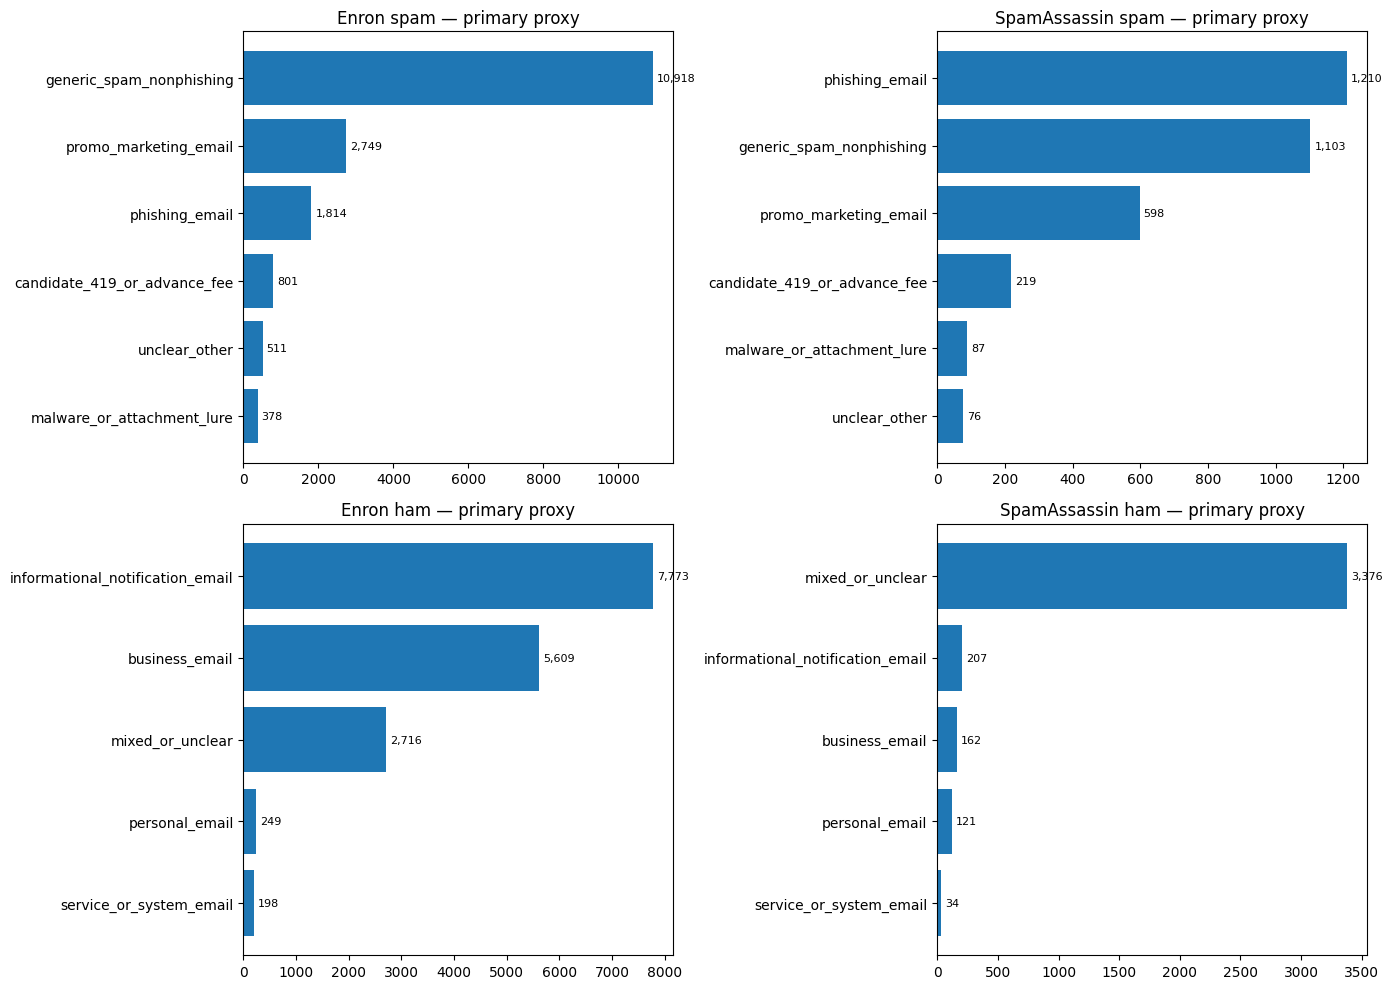

Saved /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/figures/structure/enron_sa_primary_proxy_distribution.png

Combined primary-proxy counts (saved to outputs/tables):
                                  enron_spam  sa_spam  enron_ham  sa_ham
business_email                             0        0       5609     162
candidate_419_or_advance_fee             801      219          0       0
generic_spam_nonphishing               10918     1103          0       0
informational_notification_email           0        0       7773     207
malware_or_attachment_lure               378       87          0       0
mixed_or_unclear                           0        0       2716    3376
personal_email                             0        0        249     121
phishing_email                          1814     1210          0       0
promo_marketing_email                   2749      598          0       0
service_or_system_email                    0        0        198      34
unclear_other

In [8]:
# ── 7. Bar charts: primary distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def barh_counts(ax, s: pd.Series, title: str):
    s = s.value_counts().sort_values(ascending=True)
    ax.barh(s.index.astype(str), s.values)
    ax.set_title(title)
    for i, v in enumerate(s.values):
        ax.text(v + 0.01 * max(s.values, default=1), i, f"{v:,}", va="center", fontsize=8)

barh_counts(axes[0, 0], df_es["spam_primary"], "Enron spam — primary proxy")
barh_counts(axes[0, 1], df_ss["spam_primary"], "SpamAssassin spam — primary proxy")
barh_counts(axes[1, 0], df_eh["ham_primary"], "Enron ham — primary proxy")
barh_counts(axes[1, 1], df_sh["ham_primary"], "SpamAssassin ham — primary proxy")

plt.tight_layout()
fig_path = OUT_FIGS / "enron_sa_primary_proxy_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")

# Wide summary table
summary = pd.DataFrame({
    "enron_spam": df_es["spam_primary"].value_counts(),
    "sa_spam": df_ss["spam_primary"].value_counts(),
    "enron_ham": df_eh["ham_primary"].value_counts(),
    "sa_ham": df_sh["ham_primary"].value_counts(),
}).fillna(0).astype(int)
summary.to_csv(OUT_TABLES / "enron_sa_primary_proxy_counts.csv")
print("\nCombined primary-proxy counts (saved to outputs/tables):")
print(summary.to_string())

In [10]:
# ── 8. Manual audit samples (random, stratified by primary class) ──────────
N_SAMPLE = 5
random.seed(42)


def show_samples(df: pd.DataFrame, col: str, text_col: str, title: str) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    for cls in sorted(df[col].dropna().unique()):
        sub = df[df[col] == cls]
        k = min(N_SAMPLE, len(sub))
        samp = sub.sample(k, random_state=42) if k else sub
        print(f"\n── {cls}  (n_total={len(sub):,}, showing {k}) ──")
        for i, (_, row) in enumerate(samp.iterrows(), 1):
            txt = str(row.get(text_col, "")).replace("\n", " ")
            subj = str(row.get("subject", ""))[:80]
            print(f"  [{i}] subj={subj!r}")
            print(f"      body={txt!r}...")

show_samples(df_es, "spam_primary", "text", "AUDIT: Enron spam (proxy primary)")
show_samples(df_ss, "spam_primary", "text", "AUDIT: SpamAssassin spam (proxy primary)")
show_samples(df_eh, "ham_primary", "text", "AUDIT: Enron ham (proxy primary)")
show_samples(df_sh, "ham_primary", "text", "AUDIT: SpamAssassin ham (proxy primary)")


AUDIT: Enron spam (proxy primary)

── candidate_419_or_advance_fee  (n_total=801, showing 5) ──
  [1] subj='hello !'
      body='good day .\r adiu'...
  [2] subj='bless you dear'
      body="from : mrs . esther alan buch ,\r please endeavour to use it for the children of god .\r i am the above named person from malaysia but now undergoing medical treatment\r . i am married to late dr . alan george buch who worked with malaysia embassy\r in south africa for nine years before he died in the year 2003 . we were\r married for eleven years without a child .\r he died after a brief illness that lasted for only four days . before his\r death we were both born again christians . since his death i decided not to\r re - marry or get a child outside my matrimonial home which the bible is against .\r i got your contact from a christian journal . when my late husband was alive\r he deposited the sum of $ 8 . 6 million ( eight million six hundred thousand u . s .\r dollars ) in my name with one fin

In [11]:
# ── 9. Cross-source note: SpamAssassin spam duplicates ────────────────────
import hashlib

def md5txt(t: str) -> str:
    return hashlib.md5((t or "").strip().encode("utf-8", errors="replace")).hexdigest()

sa_spam_hashes = [md5txt(r.get("text", "")) for r in sa_spam]
u_sa = len(set(sa_spam_hashes))
print(f"SpamAssassin spam: raw={len(sa_spam):,}, unique text MD5={u_sa:,}, "
      f"dup rate={100*(len(sa_spam)-u_sa)/len(sa_spam):.1f}%")
print("(Дубли в основном из пересечения архивов 20030228_spam_2 и 20050311_spam_2; см. explore_sources.)")

SpamAssassin spam: raw=3,293, unique text MD5=1,630, dup rate=50.5%
(Дубли в основном из пересечения архивов 20030228_spam_2 и 20050311_spam_2; см. explore_sources.)
